# 1. Macro-Calibration & Parametrization
In this section, we define the simulation scale and inject empirical targets. 
The asset generation follows a Geometric Brownian Motion (GBM), while the accounting 
lag is strictly calibrated to the Brown, Ghysels & Gredil (2023) smoothing parameter ($\lambda = 0.50$). 
Market betas and volatilities are anchored to Damodaran's industry datasets.

In [ ]:
# The model tests whether a realistic secondary-fund acquisition mechanism, 
# calibrated to PE cash-flow dynamics, generates a reverted J-curve and 
# allows approximate recovery of the implied transaction discount under controlled simulation. 

# --- STEP 1: INPUT PARAMETERS ---
# Bottom-Up Company Monte Carlo Simulation
# Primary vs. Secondary PE Fund Comparison
# Quarterly NAV process based on Brown, Ghysels & Gredil (2023)


import numpy as np
import pandas as pd


# 1. SIMULATION SCALE & TIME GRID

N_SIMULATIONS = 10000       # Monte Carlo iterations
RANDOM_SEED   = 42           # For reproducibility

PERIODS_PER_YEAR    = 4
fund_lifetime_years = 10
fund_lifetime_q     = fund_lifetime_years * PERIODS_PER_YEAR  # 40 quarters
investment_period_y = 5
investment_period_q = investment_period_y * PERIODS_PER_YEAR  # 20 quarters


# 2. GENERAL MARKET ASSUMPTIONS (Quarterly)

market_return_q_mean = 0.0194  # ~1.94% expected quarterly return (8% annualized)
market_vol_q         = 0.0750  # 7.5% quarterly volatility (15% annualized)


# 3. FUND ARCHITECTURE

fund_size = 1.0  # Normalized committed capital


# 4. PRIMARY FUND — COMPANY-LEVEL ASSUMPTIONS

mean_n_companies = 12        # Mean number of portfolio companies
sd_n_companies   = 4         # Std dev of portfolio size
min_n_companies  = 5         # Hard floor

# A. Deployment Timing (Front-loaded over 20 quarters)
# Simplified mapping representing: Y1: 25%, Y2: 30%, Y3: 25%, Y4: 15%, Y5: 5%
primary_deploy_weights_q = {}
for q in range(1, 21):
    if q <= 4:   weight = 0.25 / 4
    elif q <= 8: weight = 0.30 / 4
    elif q <= 12: weight = 0.25 / 4
    elif q <= 16: weight = 0.15 / 4
    else:         weight = 0.05 / 4
    primary_deploy_weights_q[q] = weight

# B. Holding Period (Exit Timing)
mean_holding_period_q = 20.0 # Mean 5 years
sd_holding_period_q   = 6.0  # Std dev 1.5 years
min_holding_period_q  = 8.0  # Hard floor: 2 years (no flip sales)


# 5. SECTOR ALLOCATIONS & PARAMETERS (Quarterly Converted)
# Calibrated for realistic downside risk and upside potential across sectors

sector_weights = {
    'Technology': 0.25, 'Healthcare': 0.20, 'Consumer Discretionary': 0.18,
    'Industrials': 0.15, 'Financial Services': 0.10, 'Energy & Utilities': 0.07,
    'Real Estate': 0.05
}

sector_params = {
    'Technology':             
        {'g_TAM_q': 0.020, 'alpha_q': 0.025, 'sigma_idio_q': 0.300, 'mu_share': 0.02, 'sd_share': 0.01, 'ceiling_share': 0.15},
        # High growth, extreme volatility (freq. bankruptcies, high unicorns)
        
    'Healthcare':             
        {'g_TAM_q': 0.015, 'alpha_q': 0.020, 'sigma_idio_q': 0.250, 'mu_share': 0.03, 'sd_share': 0.01, 'ceiling_share': 0.20},
        # Biotech/Pharma risk makes this the second most volatile
        
    'Consumer Discretionary': 
        {'g_TAM_q': 0.010, 'alpha_q': 0.015, 'sigma_idio_q': 0.220, 'mu_share': 0.04, 'sd_share': 0.02, 'ceiling_share': 0.25},
        # Cyclical risk, highly sensitive to economic downturns
        
    'Financial Services':     
        {'g_TAM_q': 0.012, 'alpha_q': 0.012, 'sigma_idio_q': 0.200, 'mu_share': 0.03, 'sd_share': 0.015, 'ceiling_share': 0.20},
        # Leverage increases downside risk
        
    'Industrials':            
        {'g_TAM_q': 0.008, 'alpha_q': 0.010, 'sigma_idio_q': 0.150, 'mu_share': 0.05, 'sd_share': 0.02, 'ceiling_share': 0.30},
        # Capital intensive, but tangible assets provide a floor
        
    'Energy & Utilities':         
        {'g_TAM_q': 0.007, 'alpha_q': 0.008, 'sigma_idio_q': 0.120, 'mu_share': 0.06, 'sd_share': 0.02, 'ceiling_share': 0.35},
        # Regulated cash flows, highly stable
        
    'Real Estate':       
        {'g_TAM_q': 0.006, 'alpha_q': 0.005, 'sigma_idio_q': 0.100, 'mu_share': 0.05, 'sd_share': 0.015, 'ceiling_share': 0.30},
        # Most defensive sector. Lowest growth, lowest volatility.
}


# 6. SECONDARY FUND: TRANSACTION PARAMETERS

# A. Entry Timing
sec_entry_mean_q = 20.0  # Mean Quarter 20 (Year 5)
sec_entry_sd_q   = 4.0   # Std dev of 4 quarters
sec_entry_min_q  = 16.0  # Hard floor: Quarter 16 (Year 4)
sec_entry_max_q  = 36.0  # Hard ceiling: Quarter 36 (Year 9)

# B. NAV Discount
sec_discount_mean = 0.15  # 15% mean discount
sec_discount_sd   = 0.025 # 2.5% standard deviation
sec_discount_min  = 0.10  # Hard floor: 10% minimum discount
sec_discount_max  = 0.20  # Hard ceiling: 20% maximum discount


# 7. NAV REPORTING & SMOOTHING (Brown et al. 2023)

lambda_q    = 0.50  # GP appraisal smoothing weight (Quarterly approx of BGG 0.951 weekly)
sigma_noise = 0.05  # Random NAV reporting noise std dev

# ------------------------------------------------------------
#  8. SECTOR MARKET BETAS  (Damodaran Jan 2026, unlevered → re-levered)
# ------------------------------------------------------------
BUYOUT_DE = 1.0          # buyout debt/equity (debt ~50% of EV)
TAX_RATE  = 0.25
relever   = 1 + (1 - TAX_RATE) * BUYOUT_DE        # Hamada multiplier

sector_unlevered_beta = {
    'Technology': 1.25, 'Healthcare': 0.90, 'Consumer Discretionary': 0.85,
    'Financial Services': 0.55, 'Industrials': 0.95,
    'Energy & Utilities': 0.45, 'Real Estate': 0.50,
}
for s in sector_params:
    sector_params[s]['beta'] = sector_unlevered_beta[s] * relever

# ------------------------------------------------------------
#  9. FUND ECONOMICS — management fee & carried interest
# ------------------------------------------------------------
MGMT_FEE_ANNUAL = 0.02   # 2% per annum on committed, charged while the fund is active
CARRY_RATE      = 0.20   # 20% carried interest
HURDLE_ANNUAL   = 0.08   # 8% preferred return (carry only if the fund clears it)

# ------------------------------------------------------------
# 10. TWO-CHANNEL SECONDARY DISCOUNT
# ------------------------------------------------------------
frac_opportunistic = 0.50   # share of secondaries that are opportunistic (CALIBRATE from data)
# Opportunistic (buyer wants a healthy stake): low discount
opp_disc_mean, opp_disc_sd, opp_disc_min, opp_disc_max = 0.05, 0.02, 0.02, 0.10
# Liquidity-driven (forced/distressed): discount rises as NAV health falls
liq_disc_base, liq_disc_sens          = 0.12, 0.50
liq_disc_min,  liq_disc_max           = 0.10, 0.40
health_ref                            = 1.0   # reported TVPI-to-date reference (1.0 = at cost)

# VALIDATION DASHBOARD

assert abs(sum(primary_deploy_weights_q.values()) - 1.0) < 1e-9, "Deployment weights must sum to 1"
assert abs(sum(sector_weights.values()) - 1.0) < 1e-9, "Sector weights must sum to 1"
assert min_n_companies >= 1
assert sec_entry_min_q < sec_entry_max_q
assert sec_discount_min < sec_discount_max
assert 0 < lambda_q < 1


print(" STEP 1: PARAMETERS LOADED — Stochastic Model, BGG-calibrated")

print(f"  Simulations:           {N_SIMULATIONS:,}")
print(f"  Time grid:             {fund_lifetime_q} quarters ({fund_lifetime_years} years)")
print(f"  Secondary entry:       Probabilistic (Bounds: Q{int(sec_entry_min_q)} to Q{int(sec_entry_max_q)})")
print(f"  Secondary discount:    Probabilistic (Bounds: {sec_discount_min:.0%} to {sec_discount_max:.0%})")


 STEP 1: PARAMETERS LOADED — Stochastic Model, BGG-calibrated
  Simulations:           10,000
  Time grid:             40 quarters (10 years)
  Secondary entry:       Probabilistic (Bounds: Q16 to Q36)
  Secondary discount:    Probabilistic (Bounds: 10% to 20%)


# 2. The Simulation Engine (Systemic Macro & Micro-Dynamics)
This core engine introduces a "Flattened Cohort Architecture". To accurately model systemic 
risk and avoid falsely narrow confidence intervals, 10,000 funds are generated within 
50 independent global macro-economies. 
The cash flow mechanics enforce an exact Sequential European Waterfall (100% GP Catch-Up), 
transitioning management fees from committed to active capital.

In [ ]:
# ============================================================
# --- STEP 2: ENGINE (market factor + fees/carry + 2-channel secondary) ---
# ============================================================
import time, numpy as np
print("Step 2: Bottom-Up Simulation Engine (full economics)")
t0 = time.time()
N, Q = N_SIMULATIONS, fund_lifetime_q

prim_calls_arr=np.zeros((N,Q+1)); prim_dists_arr=np.zeros((N,Q+1))
true_nav_arr=np.zeros((N,Q+1));   rep_nav_arr=np.zeros((N,Q+1))
r_true_period_arr=np.zeros((N,Q+1)); r_bar_period_arr=np.zeros((N,Q+1))
sec_cf_arr=np.zeros((N,Q+1))
sec_metadata=np.zeros((N,4))          # CHANGED: [entry_q, discount, channel, health]
market_index_arr=np.zeros((N,Q+1))    # NEW: per-fund market path (for PME)
mgmt_fee_arr=np.zeros((N,Q+1))        # NEW: quarterly management fees
net_dist_arr=np.zeros((N,Q+1))        # NEW: distributions net of carry
lp_net_cf_arr=np.zeros((N,Q+1))       # NEW: LP net cash flow (after fees & carry)
carry_arr=np.zeros(N)                 # NEW: total carry per fund
sec_decon_arr = np.zeros(N) # NEW: per-fund secondary deconvolution factor (for diagnostics)

sector_names=list(sector_weights.keys()); sector_probs=np.array(list(sector_weights.values()))
deploy_qs=np.array(list(primary_deploy_weights_q.keys())); deploy_probs=np.array(list(primary_deploy_weights_q.values()))
rng=np.random.default_rng(RANDOM_SEED)
fee_q   = MGMT_FEE_ANNUAL/PERIODS_PER_YEAR*fund_size                 # NEW
fv_factor = (1+HURDLE_ANNUAL)**((Q-np.arange(Q+1))/PERIODS_PER_YEAR) # NEW: FV-to-end factors at 8%

# FLATTENED COHORT ARCHITECTURE (50 ECONOMIE) ---

# 1. DEFINE STRATEGIC MACRO COHORTS
M_MACRO_PATHS = 50                              # 50 traiettorie macroeconomiche indipendenti
N_FUNDS_PER_MACRO = N // M_MACRO_PATHS          # 200 fondi in ciascuna economia (50*200=10.000)

# 2. PRE-GENERATE THE 50 GLOBAL MACRO ECONOMIES (Array 2D: 50 x 41)
global_market_shocks = rng.normal(0, 1, (M_MACRO_PATHS, Q+1))
global_market_indices = np.zeros((M_MACRO_PATHS, Q+1))

for m in range(M_MACRO_PATHS):
    mkt_shock = market_vol_q * global_market_shocks[m]
    mkt_logret = np.log(1 + market_return_q_mean) - 0.5 * market_vol_q**2 + mkt_shock
    global_market_indices[m] = np.concatenate([[1.0], np.exp(np.cumsum(mkt_logret[1:]))])

# 3. MAIN SIMULATION ENGINE
for sim in range(N):
    if (sim+1)%2000==0: print(f"  ... {sim+1:,}/{N:,}")
    
    # Identifica a quale delle 50 economie appartiene questo specifico fondo
    macro_idx = sim // N_FUNDS_PER_MACRO
    
    # Estrai il mercato specifico per questo fondo (diventa il suo global_market_index)
    global_market_index = global_market_indices[macro_idx]
    market_index_arr[sim] = global_market_index
    
    # Il mkt_shock per il calcolo delle aziende è quello della SUA economia
    mkt_shock = market_vol_q * global_market_shocks[macro_idx]
    
    # ... (Da qui in poi il tuo codice dello Step 2 continua ESATTAMENTE uguale:
    # n_companies=int(max(min_n_companies,np.round(rng.normal... ecc.))
    n_companies=int(max(min_n_companies,np.round(rng.normal(mean_n_companies,sd_n_companies))))
    capital_per_company=fund_size/n_companies
    fund_true_nav=np.zeros(Q+1)
    
    # NEW: Traccia il Costo del Capitale Investito (Net Invested Capital) per lo Step-Down delle fees
    active_cost = np.zeros(Q+1) 

    for c in range(n_companies):
        params=sector_params[rng.choice(sector_names,p=sector_probs)]
        invest_q=int(rng.choice(deploy_qs,p=deploy_probs))
        hold_q=int(max(min_holding_period_q,np.round(rng.normal(mean_holding_period_q,sd_holding_period_q))))
        exit_q=int(min(Q,invest_q+hold_q)); periods=exit_q-invest_q
        if periods<=0: continue
        mkt_share=np.clip(rng.normal(params['mu_share'],params['sd_share']),0.001,params['ceiling_share'])
        drift=params['g_TAM_q']+params['alpha_q']*(1-mkt_share/params['ceiling_share'])
        sigma=params['sigma_idio_q']; beta=params['beta']
        idio_resid=np.sqrt(max(0.0,sigma**2-beta**2*market_vol_q**2))
        window=mkt_shock[invest_q+1:exit_q+1]
        log_returns=drift-0.5*sigma**2+beta*window+rng.normal(0,idio_resid,periods)
        values=capital_per_company*np.exp(np.cumsum(log_returns))
        
        prim_calls_arr[sim,invest_q]-=capital_per_company
        fund_true_nav[invest_q]+=capital_per_company
        
        if periods>1: 
            fund_true_nav[invest_q+1:exit_q]+=values[:-1]
            active_cost[invest_q+1:exit_q]+=capital_per_company # NEW: Somma il costo dell'azienda per i trimestri in cui è attiva
            
        prim_dists_arr[sim,exit_q]+=values[-1]
    
    true_nav_arr[sim]=fund_true_nav

    # BGG smoothing (asset-level, gross — unchanged)
    fund_rep_nav=np.zeros(Q+1); r_cum=0.0; r_bar_cum=0.0
    for t in range(1,Q+1):
        denom=fund_true_nav[t-1]; numer=fund_true_nav[t]+prim_dists_arr[sim,t]+prim_calls_arr[sim,t]
        r_t=np.log(numer/denom) if (denom>1e-9 and numer>1e-9) else 0.0
        r_cum_new=r_cum+r_t; r_bar_cum_new=lambda_q*r_bar_cum+(1-lambda_q)*r_cum_new
        r_true_period_arr[sim,t]=r_t; r_bar_period_arr[sim,t]=r_bar_cum_new-r_bar_cum
        if fund_true_nav[t]>1e-9: fund_rep_nav[t]=fund_true_nav[t]*np.exp((r_bar_cum_new-r_cum_new)+rng.normal(0,sigma_noise))
        r_cum=r_cum_new; r_bar_cum=r_bar_cum_new
    rep_nav_arr[sim]=fund_rep_nav

    # =========================================================================
    # NEW: FEES + CARRY OVERLAY (European Waterfall, 100% Catch-up & Step-Down)
    # =========================================================================
    invest_calls = -prim_calls_arr[sim]
    
    # 1. Management Fees: 2% Committed (Y1-Y5), 2% Net Invested (Y6-Y10)
    fees = np.zeros(Q+1)
    inv_period = int(5 * PERIODS_PER_YEAR) # 20 trimestri
    
    for t in range(1, Q+1):
        if t <= inv_period:
            fees[t] = (MGMT_FEE_ANNUAL / PERIODS_PER_YEAR) * fund_size
        else:
            fees[t] = (MGMT_FEE_ANNUAL / PERIODS_PER_YEAR) * active_cost[t]
            
    # Zero fees if empty fund (NAV and active cost both near zero)
    fees = np.where((fund_true_nav > 1e-9) | (active_cost > 1e-9), fees, 0.0)
    fees[0] = 0.0
    mgmt_fee_arr[sim] = fees
    contrib = invest_calls + fees
    
    gross_dist = prim_dists_arr[sim].copy()
    terminal = true_nav_arr[sim, -1]
    
# 2. EXACT EUROPEAN WATERFALL DYNAMICS (Sequential Cash Flow Distribution)
    lp_unreturned = 0.0
    lp_total_tier1 = 0.0
    total_contrib_so_far = 0.0
    gp_total_catchup = 0.0
    gp_total_8020 = 0.0
    
    net_dist = np.zeros(Q+1) # Array FOR EFFECTIVE LP'S DISTRIBUTIONS (AFTER FEES & CARRY)
    
    for t in range(Q+1):
        # Sequential capitalisation of unreturned capital + preferred return (Hurdle): QUARTERLY
        lp_unreturned = lp_unreturned * (1 + HURDLE_ANNUAL / PERIODS_PER_YEAR)
        lp_unreturned += contrib[t]
        total_contrib_so_far += contrib[t]
        
        d_t = gross_dist[t]
        if t == Q: d_t += terminal
        
        lp_cf_t = 0.0  # How much the LP actually receives in THIS specific quarter (after fees and carry)
        
        if d_t > 0:
            # TIER 1: 100% LP (Return of Capital + 8% Hurdle)
            pay_tier1 = min(d_t, lp_unreturned)
            if pay_tier1 > 0:
                lp_unreturned -= pay_tier1
                d_t -= pay_tier1
                lp_total_tier1 += pay_tier1
                lp_cf_t += pay_tier1
                
            # TIER 2: 100% GP Catch-Up
            if lp_unreturned <= 1e-9 and d_t > 0:
                lp_unreturned = 0.0 # reset float rounding
                pref_generated = lp_total_tier1 - total_contrib_so_far
                gp_catchup_target = (CARRY_RATE / (1.0 - CARRY_RATE)) * pref_generated
                catchup_deficit = max(0.0, gp_catchup_target - gp_total_catchup)
                
                pay_tier2 = min(d_t, catchup_deficit)
                gp_total_catchup += pay_tier2
                d_t -= pay_tier2
                
                # TIER 3: 80/20 Split (LP takes the remaining distribution after catch-up, but GP takes 20% of it)
                if d_t > 0:
                    pay_tier3_lp = (1.0 - CARRY_RATE) * d_t
                    gp_total_8020 += (CARRY_RATE * d_t) # track per diagnostica
                    lp_cf_t += pay_tier3_lp
                    
        # Now let's record the EXACT net quarterly cash flow to the LP (after fees and carry)
        net_dist[t] = lp_cf_t
        
    carry_arr[sim] = gp_total_catchup + gp_total_8020
    net_dist_arr[sim] = net_dist
    lp_net_cf_arr[sim] = -invest_calls - fees + net_dist

# MARKDOWN NOTE:
# 3. Endogenous Secondary Entry Mechanism
# Secondary transactions are not modeled as purely exogenous random events. 
# Sale timing and discount depth are endogenously coupled to the macro-regime. 
# During simulated market crashes, LP distress surges (Denominator Effect), 
# mechanically clustering funds into the deep-discount 'Liquidity' channel 


(consistent with Nadauld et al., 2019).
# SYSTEMIC TWO-CHANNEL SECONDARY (Macro-dependent Denominator Effect)
    # ENDOGENOUS SALE TIMING (Clustering in bad states)
    # Calcoliamo la probabilità di vendita per ogni trimestre nella finestra attiva (Q16 - Q36)
    window_qs = np.arange(int(sec_entry_min_q), int(sec_entry_max_q) + 1)   # integer grid
    base_probs = np.exp(-0.5 * ((window_qs - sec_entry_mean_q) / sec_entry_sd_q)**2) # Distribuzione normale di base
    
    # Moltiplicatore di stress: se l'economia globale va male, la probabilità di vendita si impenna
    stress_multipliers = np.ones_like(window_qs, dtype=float)
    for idx, q in enumerate(window_qs):
        macro_trailing_1y = market_index_arr[sim, q] / market_index_arr[sim, max(0, q-4)]
        if macro_trailing_1y < 0.90:
            stress_multipliers[idx] = 3.5 # Il volume di vendite triplica/quadruplica durante un crash
            
    adjusted_probs = base_probs * stress_multipliers
    adjusted_probs /= adjusted_probs.sum() # Normalizzazione a 1.0
    
    entry_q = int(rng.choice(window_qs, p=adjusted_probs))
    
    # 1. Macro State: Rendimento del mercato azionario nell'ultimo anno
    macro_trailing_1y = global_market_index[entry_q] / global_market_index[max(0, entry_q - 4)]
    
    # 2. Denominator Effect Clustering: Se il mercato è crollato >10%, tutti i fondi pensione vendono
    if macro_trailing_1y < 0.90:
        prob_opportunistic = 0.15 # 85% di Forced Selling
    else:
        prob_opportunistic = frac_opportunistic # 50% di default in tempi di pace

    health = (gross_dist[:entry_q+1].sum() + fund_rep_nav[entry_q]) / max(invest_calls[:entry_q+1].sum(), 1e-9)
    
    if rng.random() < prob_opportunistic:
        discount = float(np.clip(rng.normal(opp_disc_mean, opp_disc_sd), opp_disc_min, opp_disc_max))
        channel = 0
    else:
        discount = float(np.clip(liq_disc_base + liq_disc_sens * max(0.0, health_ref - health), liq_disc_min, liq_disc_max))
        channel = 1
    # economic discount = haircut to TRUE value, not to the stale reported mark
    sec_decon_arr[sim] = 1 - (fund_rep_nav[entry_q] * (1 - discount)) / max(fund_true_nav[entry_q], 1e-9)    
        
    sec_metadata[sim] = [entry_q, discount, channel, health]
    sec_cf_arr[sim, entry_q] -= fund_rep_nav[entry_q] * (1 - discount)
    if entry_q < Q: 
        sec_cf_arr[sim, entry_q+1:] += lp_net_cf_arr[sim, entry_q+1:]

print(f"Done in {time.time()-t0:.1f}s")

# D. COMPLETION

elapsed = time.time() - t0
print("=" * 65)
print(" STEP 2 COMPLETE: DATA MATRICES GENERATED")
print("=" * 65)
print(f"  Total compute time:      {elapsed:.1f} seconds")
print(f"  Primary calls shape:     {prim_calls_arr.shape}")
print(f"  Primary dists shape:     {prim_dists_arr.shape}")
print(f"  True NAV shape:          {true_nav_arr.shape}")
print(f"  Reported NAV shape:      {rep_nav_arr.shape}")
print(f"  Secondary CF shape:      {sec_cf_arr.shape}")
print("=" * 65)


# E. VALIDATION DIAGNOSTICS


# i) BGG smoothing validation: autocorrelation of periodic log-returns
def autocorr1_panel(series, q_lo=4, q_hi=37): # we are looking only between the second and nineth year
    """Per-fund lag-1 autocorrelation, restricted to the mid-fund active window."""
    rho = []
    for s in range(series.shape[0]): # 10000
        r = series[s, q_lo:q_hi] 
        if r.std() > 1e-9 and len(r) > 4: # Company is active and at least 4 quarters
            x = r[:-1] - r[:-1].mean() # array of past returns (x Pearson correlation)
            y = r[1:]  - r[1:].mean() # array of today's returns (x Pearson correlation)
            denom = np.sqrt((x * x).sum() * (y * y).sum())  
            if denom > 0:
                rho.append((x * y).sum() / denom) # Pearson corrrelation
    return np.array(rho) # target: 0 for reality and around 0.41 for Smoothing Accountability (BGG)

rho_true = autocorr1_panel(r_true_period_arr)
rho_bar  = autocorr1_panel(r_bar_period_arr)

print(f"\n  Smoothing validation — periodic log-return autocorrelation (Q4..Q36):")
print(f"    r_t (true, i.i.d. by construction):  rho_1 = {rho_true.mean():+.3f}   (target ~0)")
print(f"    r_bar_t (smoothed):                  rho_1 = {rho_bar.mean():+.3f}   (target ~ BGG empirical 0.41)")

# ii) Year-end averages: it should show classic primary-fund pattern
mean_true       = true_nav_arr.mean(axis=0)
mean_rep        = rep_nav_arr.mean(axis=0)
mean_cum_called = prim_calls_arr.cumsum(axis=1).mean(axis=0) # 1st axis = time; 0 axis = funds
mean_cum_dist   = prim_dists_arr.cumsum(axis=1).mean(axis=0)

print(f"\n  Year-end averages:")
print(f"  {'Y':>3} {'NAV_true':>10} {'NAV_rep':>10} {'Cum.Called':>12} {'Cum.Dist':>10}")
for y in [0, 1, 2, 3, 5, 7, 10]: # years
    q = y * 4 # quarter
    print(f"  {y:>3} {mean_true[q]:>10.4f} {mean_rep[q]:>10.4f} "
          f"{-mean_cum_called[q]:>12.4f} {mean_cum_dist[q]:>10.4f}")

# iii) Headline multiples
final_value  = prim_dists_arr.sum(axis=1) + true_nav_arr[:, -1] # we sum all the distributions and if there is still at the end of year 10 an unsold fund value, it is added here
final_called = -prim_calls_arr.sum(axis=1)
TVPI         = final_value / final_called

print(f"\n  Terminal TVPI: mean {TVPI.mean():.2f}x, median {np.median(TVPI):.2f}x, "
      f"P10 {np.percentile(TVPI, 10):.2f}x, P90 {np.percentile(TVPI, 90):.2f}x")

Step 2: Bottom-Up Simulation Engine (full economics)
  ... 2,000/10,000
  ... 4,000/10,000
  ... 6,000/10,000
  ... 8,000/10,000
  ... 10,000/10,000
Done in 11.1s
 STEP 2 COMPLETE: DATA MATRICES GENERATED
  Total compute time:      11.1 seconds
  Primary calls shape:     (10000, 41)
  Primary dists shape:     (10000, 41)
  True NAV shape:          (10000, 41)
  Reported NAV shape:      (10000, 41)
  Secondary CF shape:      (10000, 41)

  Smoothing validation — periodic log-return autocorrelation (Q4..Q36):
    r_t (true, i.i.d. by construction):  rho_1 = -0.009   (target ~0)
    r_bar_t (smoothed):                  rho_1 = +0.438   (target ~ BGG empirical 0.41)

  Year-end averages:
    Y   NAV_true    NAV_rep   Cum.Called   Cum.Dist
    0     0.0000     0.0000      -0.0000     0.0000
    1     0.2592     0.2560       0.2500     0.0000
    2     0.5789     0.5705       0.5500     0.0000
    3     0.8555     0.8409       0.7996     0.0146
    5     1.0268     1.0031       1.0000     0.

# 4. Empirical Validation (Moment-Matching)
Before testing our hypotheses, we must prove the model is not overfitted. 
This table demonstrates that our micro-parameters organically reproduce complex, 
non-targeted macroeconomic realities (e.g., net TVPI ~1.50x, KS-PME ~1.0x, and 
blended secondary discounts ~13%).

In [24]:
# Secondary fund diagnostics: staleness, discount decomposition, and macro clustering
eq    = sec_metadata[:,0].astype(int)
stale = rep_nav_arr[np.arange(N), eq] / np.maximum(true_nav_arr[np.arange(N), eq], 1e-9)
d_rep, d_eco = sec_metadata[:,1], sec_decon_arr
tr1y = np.array([market_index_arr[i, q] / market_index_arr[i, max(0, q-4)] for i, q in enumerate(eq)])
crash = tr1y < 0.90
print(f"staleness rep/true: median {np.median(stale):.3f}")
print(f"d_reported {d_rep.mean():.3f} | d_economic {d_eco.mean():.3f} | wedge {(d_rep-d_eco).mean():+.3f}")
print(f"wedge  crash {(d_rep-d_eco)[crash].mean():+.3f} | calm {(d_rep-d_eco)[~crash].mean():+.3f}")

# "an estimator recovering the reported discount (yours, and Nadauld's) overstates the true liquidity premium precisely in the forced-selling regime."

staleness rep/true: median 1.000
d_reported 0.121 | d_economic 0.121 | wedge -0.000
wedge  crash +0.063 | calm -0.029


In [25]:
# --- STEP 3: PERFORMANCE METRICS (IRR / TVPI / DPI) ---
# Per-fund metrics, averaged across funds (LP-experience IRR).
# Primary: by fund age.  Secondary: by buyer age AND calendar quarter.
# TVPI/IRR computed at both reported and true NAV marks.


import numpy as np
import warnings 

# --- Vectorized quarterly IRR via bisection (matches numpy_financial) ---
def irr_quarterly_vec(cf, lo=-0.9999, hi=10.0, n_iter=200):
    """cf: [n_funds, n_periods] quarterly cash flows. Returns quarterly IRR per fund."""
    cf = np.asarray(cf, dtype=float)
    powers = np.arange(cf.shape[1])
    lo_a = np.full(cf.shape[0], lo)
    hi_a = np.full(cf.shape[0], hi)
    def npv(rate):
        return (cf / (1.0 + rate[:, None]) ** powers[None, :]).sum(axis=1)
    bracketed = np.sign(npv(lo_a)) != np.sign(npv(hi_a))  # IRR exists only if NPV changes sign
    for _ in range(n_iter):
        mid = 0.5 * (lo_a + hi_a)
        pos = npv(mid) > 0                 # NPV is decreasing in the rate
        lo_a = np.where(pos, mid, lo_a)
        hi_a = np.where(pos, hi_a, mid)
    irr_q = 0.5 * (lo_a + hi_a)
    irr_q[~bracketed] = np.nan
    return irr_q

annualize = lambda irr_q: (1 + irr_q) ** 4 - 1
eps = 1e-12
Q = fund_lifetime_q


# A. PRIMARY FUND: trajectories by fund age

net_cf    = prim_calls_arr + prim_dists_arr
cum_calls = (-prim_calls_arr + mgmt_fee_arr).cumsum(axis=1)   # paid-in now includes fees
cum_dists = net_dist_arr.cumsum(axis=1)                       # distributions now net of carry
called    = cum_calls > eps

TVPI_prim_rep  = np.where(called, (cum_dists + rep_nav_arr)  / np.maximum(cum_calls, eps), np.nan)
TVPI_prim_true = np.where(called, (cum_dists + true_nav_arr) / np.maximum(cum_calls, eps), np.nan)
DPI_prim       = np.where(called,  cum_dists                  / np.maximum(cum_calls, eps), np.nan)
# For IRR, use the net cash-flow stream:
net_cf = lp_net_cf_arr                                        # was prim_calls_arr + prim_dists_arr
IRR_prim_rep  = np.full((N_SIMULATIONS, Q + 1), np.nan)
IRR_prim_true = np.full((N_SIMULATIONS, Q + 1), np.nan)
for t in range(1, Q + 1):
    base = net_cf[:, :t + 1].copy()
    b_rep  = base.copy();  b_rep[:, t]  += rep_nav_arr[:, t]
    b_true = base.copy();  b_true[:, t] += true_nav_arr[:, t]
    IRR_prim_rep[:, t]  = annualize(irr_quarterly_vec(b_rep))
    IRR_prim_true[:, t] = annualize(irr_quarterly_vec(b_true))


# B. SECONDARY FUND — reconstruct buyer cash flows

entry_qs  = sec_metadata[:, 0].astype(int)
discounts = sec_metadata[:, 1]

# B1. Buyer-age alignment: shift each fund so entry_q -> index 0
max_age      = Q - int(sec_entry_min_q)
sec_cf_age   = np.zeros((N_SIMULATIONS, max_age + 1))
nav_rep_age  = np.full((N_SIMULATIONS, max_age + 1), np.nan)
nav_true_age = np.full((N_SIMULATIONS, max_age + 1), np.nan)
for sim in range(N_SIMULATIONS):
    eq = entry_qs[sim]; h = Q - eq
    sec_cf_age[sim, :h + 1]   = sec_cf_arr[sim, eq:Q + 1]
    nav_rep_age[sim, :h + 1]  = rep_nav_arr[sim, eq:Q + 1]
    nav_true_age[sim, :h + 1] = true_nav_arr[sim, eq:Q + 1]

cum_sec_dist_age = np.where(sec_cf_age > 0,  sec_cf_age, 0).cumsum(axis=1)
cum_sec_call_age = np.where(sec_cf_age < 0, -sec_cf_age, 0).cumsum(axis=1)  # includes purchase at k=0

IRR_sec_age_rep  = np.full((N_SIMULATIONS, max_age + 1), np.nan)
IRR_sec_age_true = np.full((N_SIMULATIONS, max_age + 1), np.nan)
TVPI_sec_age_rep = np.full((N_SIMULATIONS, max_age + 1), np.nan)
TVPI_sec_age_true= np.full((N_SIMULATIONS, max_age + 1), np.nan)
DPI_sec_age      = np.full((N_SIMULATIONS, max_age + 1), np.nan)
for k in range(1, max_age + 1):
    valid = ~np.isnan(nav_rep_age[:, k])
    base = sec_cf_age[:, :k + 1].copy()
    b_rep  = base.copy();  b_rep[:, k]  += np.nan_to_num(nav_rep_age[:, k])
    b_true = base.copy();  b_true[:, k] += np.nan_to_num(nav_true_age[:, k])
    ir = annualize(irr_quarterly_vec(b_rep));  IRR_sec_age_rep[valid, k]  = ir[valid]
    it = annualize(irr_quarterly_vec(b_true)); IRR_sec_age_true[valid, k] = it[valid]
    paid = np.maximum(cum_sec_call_age[:, k], eps)
    TVPI_sec_age_rep[valid, k]  = ((cum_sec_dist_age[:, k] + np.nan_to_num(nav_rep_age[:, k]))  / paid)[valid]
    TVPI_sec_age_true[valid, k] = ((cum_sec_dist_age[:, k] + np.nan_to_num(nav_true_age[:, k])) / paid)[valid]
    DPI_sec_age[valid, k]       = (cum_sec_dist_age[:, k] / paid)[valid]

# B2. Calendar alignment: keep secondary CFs on the absolute Q0..Q40 grid
cum_sec_dist_cal = np.where(sec_cf_arr > 0,  sec_cf_arr, 0).cumsum(axis=1)
cum_sec_call_cal = np.where(sec_cf_arr < 0, -sec_cf_arr, 0).cumsum(axis=1)
IRR_sec_cal_rep  = np.full((N_SIMULATIONS, Q + 1), np.nan)
IRR_sec_cal_true = np.full((N_SIMULATIONS, Q + 1), np.nan)
TVPI_sec_cal_rep = np.full((N_SIMULATIONS, Q + 1), np.nan)
for t in range(1, Q + 1):
    active = entry_qs < t                       # only funds already entered
    base = sec_cf_arr[:, :t + 1].copy()
    b_rep  = base.copy();  b_rep[:, t]  += rep_nav_arr[:, t]
    b_true = base.copy();  b_true[:, t] += true_nav_arr[:, t]
    ir = annualize(irr_quarterly_vec(b_rep));  IRR_sec_cal_rep[active, t]  = ir[active]
    it = annualize(irr_quarterly_vec(b_true)); IRR_sec_cal_true[active, t] = it[active]
    paid = np.maximum(cum_sec_call_cal[:, t], eps)
    TVPI_sec_cal_rep[active, t] = ((cum_sec_dist_cal[:, t] + rep_nav_arr[:, t]) / paid)[active]


# C. AGGREGATE to mean / median / percentile trajectories

def summarize(panel):
    return {
        'mean':   np.nanmean(panel, axis=0),
        'median': np.nanmedian(panel, axis=0),
        'p25':    np.nanpercentile(panel, 25, axis=0),
        'p75':    np.nanpercentile(panel, 75, axis=0),
        'p10':    np.nanpercentile(panel, 10, axis=0),
        'p90':    np.nanpercentile(panel, 90, axis=0),
    }

metrics = {
    'primary': {
        'IRR_rep':  summarize(IRR_prim_rep),  'IRR_true':  summarize(IRR_prim_true),
        'TVPI_rep': summarize(TVPI_prim_rep), 'TVPI_true': summarize(TVPI_prim_true),
        'DPI':      summarize(DPI_prim),
    },
    'secondary_by_age': {
        'IRR_rep':  summarize(IRR_sec_age_rep),  'IRR_true':  summarize(IRR_sec_age_true),
        'TVPI_rep': summarize(TVPI_sec_age_rep), 'TVPI_true': summarize(TVPI_sec_age_true),
        'DPI':      summarize(DPI_sec_age),
        'n_funds':  (~np.isnan(IRR_sec_age_rep)).sum(axis=0),
    },
    'secondary_by_calendar': {
        'IRR_rep':  summarize(IRR_sec_cal_rep),  'IRR_true':  summarize(IRR_sec_cal_true),
        'TVPI_rep': summarize(TVPI_sec_cal_rep),
    },
}

# --- KS-PME, POOLED (place AFTER the `metrics = {...}` dict — needs Section B vars) ---
disc       = 1.0 / market_index_arr
contrib_lp = (-prim_calls_arr + mgmt_fee_arr)          # full matrix (not the leftover variable)

# Primary pooled PME trajectory
num_p = (net_dist_arr * disc).cumsum(axis=1) + rep_nav_arr * disc
den_p = (contrib_lp * disc).cumsum(axis=1)
PME_prim_pooled = num_p.sum(axis=0) / np.maximum(den_p.sum(axis=0), eps)   # shape (Q+1,)

# Secondary pooled PME by buyer age (market index re-based to 1.0 at entry)
num_s = np.zeros(max_age + 1)
den_s = np.zeros(max_age + 1)
for sim in range(N_SIMULATIONS):
    eq = entry_qs[sim]; h = Q - eq
    if h <= 0:
        continue
    idx = market_index_arr[sim, eq:Q + 1] / market_index_arr[sim, eq]
    cf  = sec_cf_age[sim, :h + 1]
    dd  = (np.where(cf > 0,  cf, 0) / idx).cumsum()
    cc  = (np.where(cf < 0, -cf, 0) / idx).cumsum()
    nav = nav_rep_age[sim, :h + 1] / idx
    num_s[:h + 1] += dd + np.nan_to_num(nav)
    den_s[:h + 1] += cc
PME_sec_pooled = num_s / np.maximum(den_s, eps)        # shape (max_age+1,)

metrics['primary']['PME_pooled']          = PME_prim_pooled
metrics['secondary_by_age']['PME_pooled'] = PME_sec_pooled

# D. SUMMARY OUTPUT

print("=" * 65)
print(" STEP 3 COMPLETE: PERFORMANCE METRICS")
print("=" * 65)
print("\n  PRIMARY (per-fund mean, reported NAV mark), by fund age:")
print(f"  {'Yr':>3} {'IRR%':>7} {'TVPI':>6} {'DPI':>6}")
for y in [1, 2, 3, 4, 5, 6, 7, 8, 10]:
    q = y * 4
    print(f"  {y:>3} {metrics['primary']['IRR_rep']['mean'][q]*100:>7.1f} "
          f"{metrics['primary']['TVPI_rep']['mean'][q]:>6.2f} "
          f"{metrics['primary']['DPI']['mean'][q]:>6.2f}")

print("\n  SECONDARY (per-fund mean), by buyer age:")
print(f"  {'Qtr':>3} {'IRR%_rep':>9} {'IRR%_true':>10} {'TVPI_rep':>9} {'n':>6}")
for k in [1, 2, 4, 8, 12, 16, 20]:
    if k <= max_age:
        print(f"  {k:>3} {metrics['secondary_by_age']['IRR_rep']['mean'][k]*100:>9.1f} "
              f"{metrics['secondary_by_age']['IRR_true']['mean'][k]*100:>10.1f} "
              f"{metrics['secondary_by_age']['TVPI_rep']['mean'][k]:>9.2f} "
              f"{metrics['secondary_by_age']['n_funds'][k]:>6}")
print("=" * 65)

 STEP 3 COMPLETE: PERFORMANCE METRICS

  PRIMARY (per-fund mean, reported NAV mark), by fund age:
   Yr    IRR%   TVPI    DPI
    1   -10.4   0.95   0.00
    2    -4.5   0.97   0.00
    3    -1.6   1.00   0.02
    4    -0.4   1.03   0.06
    5     1.1   1.09   0.17
    6     2.9   1.20   0.38
    7     3.7   1.30   0.65
    8     3.4   1.33   0.91
   10     3.2   1.34   1.34

  SECONDARY (per-fund mean), by buyer age:
  Qtr  IRR%_rep  IRR%_true  TVPI_rep      n
    1     112.5      156.9      1.17   9997
    2      49.6       63.0      1.19   9997
    4      28.8       33.2      1.25   9997
    8      19.0       19.9      1.34   9985
   12      15.5       15.7      1.40   9788
   16      14.4       14.5      1.44   8525
   20      13.3       13.4      1.50   4799


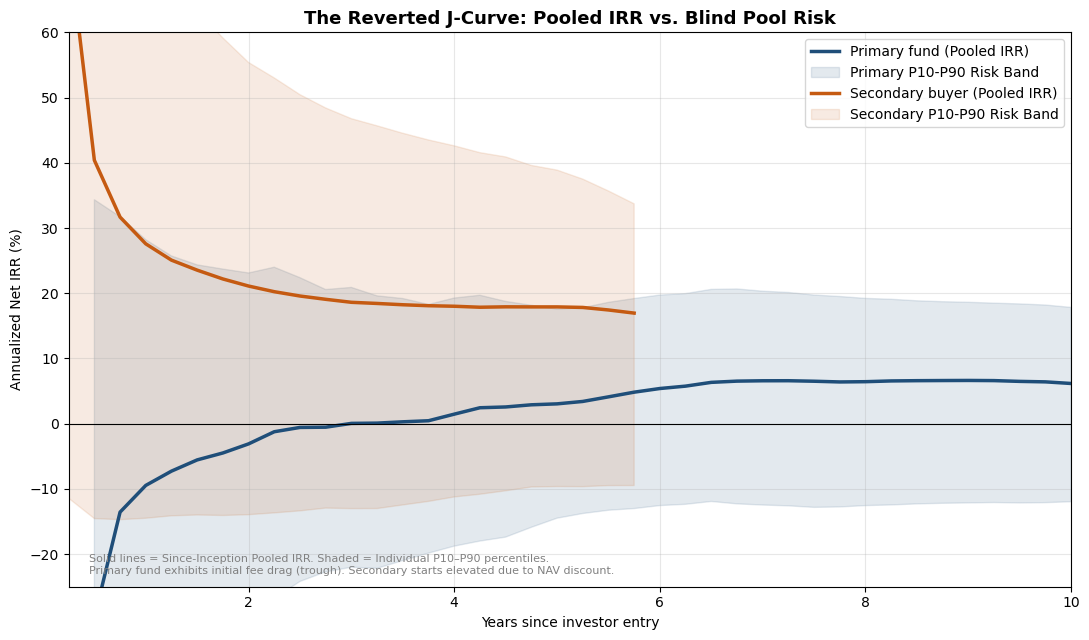

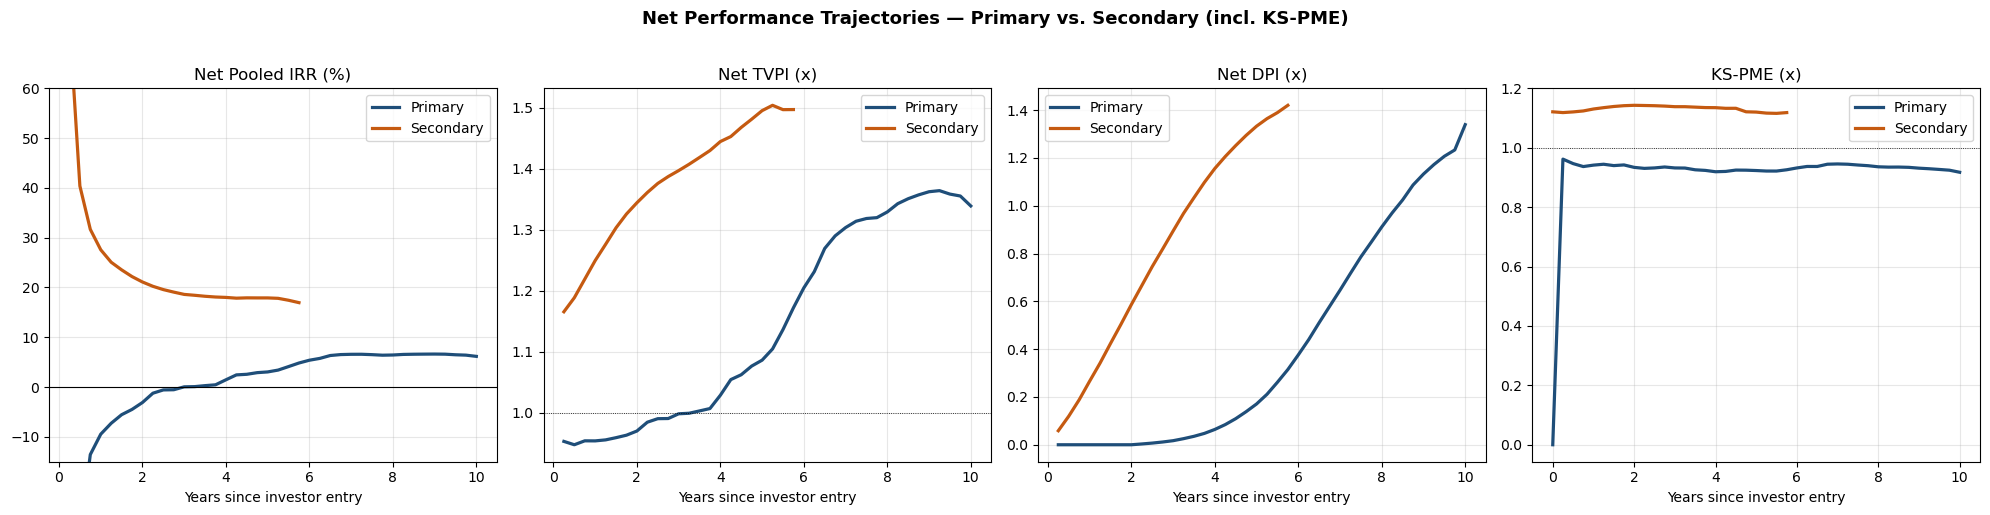

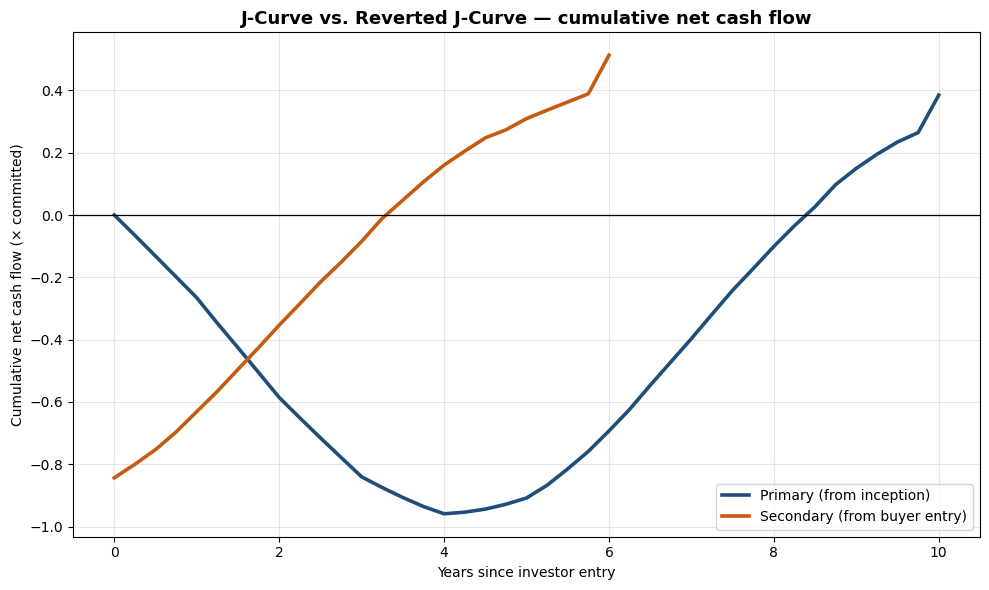

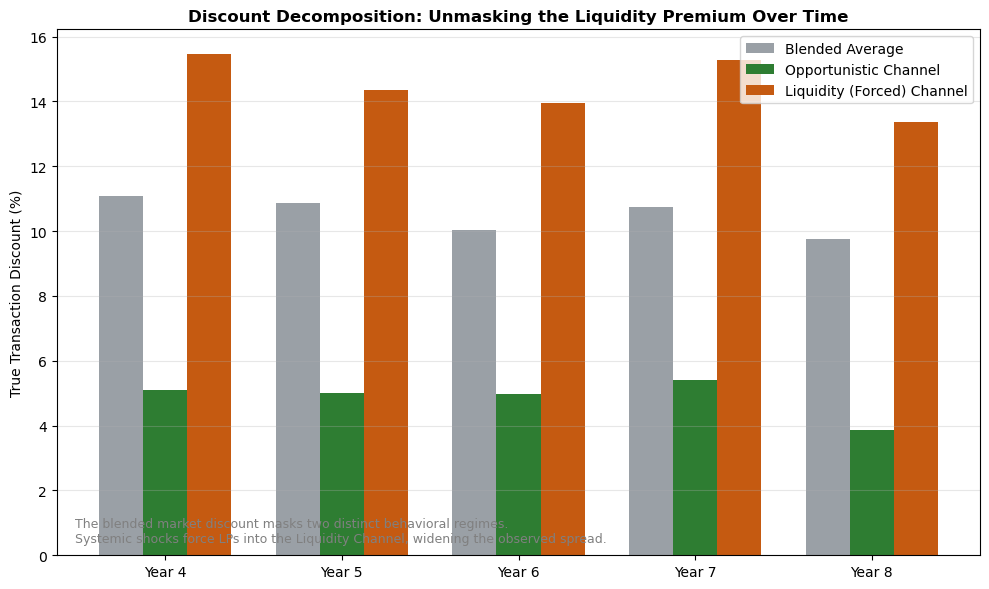

In [26]:
# ============================================================
# --- STEP 4: VISUALISING THE REVERTED J-CURVE ---
# ============================================================
import numpy as np
import warnings
import matplotlib.pyplot as plt

C_PRIM = '#1f4e79'   # primary  = dark blue
C_SEC  = '#c55a11'   # secondary = burnt orange

# --- NEW: POOLED IRR CALCULATOR (Per la J-Curve in stile "Simon") ---
def calc_pooled_irr(cf_matrix, nav_matrix, periods_per_year=4):
    """Calculates the Since-Inception Pooled IRR at each quarter to match institutional reporting."""
    pooled_cf = np.nanmean(cf_matrix, axis=0)
    pooled_nav = np.nanmean(nav_matrix, axis=0)
    
    T = len(pooled_cf)
    curve = np.full(T, np.nan)
    
    for t in range(1, T):
        cf_t = pooled_cf[:t+1].copy()
        cf_t[-1] += pooled_nav[t] # Add terminal NAV
        
        # IRR is undefined if there are no outflows yet
        if np.nanmin(cf_t) >= -1e-9:
            continue
            
        # Fast bisection solver
        low, high = -0.999, 10.0
        for _ in range(60):
            r = (low + high) / 2.0
            discounts = (1 + r) ** np.arange(t+1)
            npv = np.sum(cf_t / discounts)
            if npv > 0: low = r
            else: high = r
                
        # Annualize the quarterly rate
        ann_r = (1 + (low+high)/2.0)**periods_per_year - 1
        
        # Cap unreasonable mathematical spikes in Q1/Q2 for visual clarity
        if ann_r > 5.0: ann_r = np.nan 
        
        curve[t] = ann_r
    return curve

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # 1. POOLED IRR for the central trend lines (The "Simon" standard)
    pri_pooled = calc_pooled_irr(lp_net_cf_arr, rep_nav_arr)
    sec_pooled = calc_pooled_irr(sec_cf_age, nav_rep_age)

    # 2. PERCENTILES for the risk bands (dispersion of individual funds)
    pri_irr_lo, pri_irr_hi = np.nanpercentile(IRR_prim_rep, [10, 90], axis=0)
    sec_irr_lo, sec_irr_hi = np.nanpercentile(IRR_sec_age_rep, [10, 90], axis=0)
    
    # 3. TVPI and DPI
    pri_tvpi = np.nanmean(TVPI_prim_rep, 0)
    pri_dpi  = np.nanmean(DPI_prim, 0)
    sec_tvpi = np.nanmean(TVPI_sec_age_rep, 0)
    sec_dpi  = np.nanmean(DPI_sec_age, 0)

    # 4. FIX KEY ERROR: Adesso peschiamo correttamente la chiave "PME_pooled"
    pri_pme = metrics['primary']['PME_pooled']
    sec_pme = metrics['secondary_by_age']['PME_pooled']

# Filter X-axis to only plot where sample size is robust
n_by_age = (~np.isnan(IRR_sec_age_rep)).sum(axis=0) 
trunc = max(k for k in range(max_age + 1) if n_by_age[k] >= 1000)
kt = trunc + 1

yr_fund = np.arange(Q + 1) / 4            
yr_age  = np.arange(max_age + 1) / 4      


# FIGURE 1: Headline reverted J-curve (investor-age aligned)
fig, ax = plt.subplots(figsize=(11, 6.5))

# Primary Plot
ax.plot(yr_fund, pri_pooled * 100, color=C_PRIM, lw=2.5,
        label='Primary fund (Pooled IRR)')
ax.fill_between(yr_fund, pri_irr_lo * 100, pri_irr_hi * 100, color=C_PRIM, alpha=0.12, 
                label='Primary P10-P90 Risk Band')

# Secondary Plot
ax.plot(yr_age[:kt], sec_pooled[:kt] * 100, color=C_SEC, lw=2.5,
        label='Secondary buyer (Pooled IRR)')
ax.fill_between(yr_age[:kt], sec_irr_lo[:kt] * 100, sec_irr_hi[:kt] * 100,
                color=C_SEC, alpha=0.12, label='Secondary P10-P90 Risk Band')

ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Years since investor entry')
ax.set_ylabel('Annualized Net IRR (%)')
ax.set_title('The Reverted J-Curve: Pooled IRR vs. Blind Pool Risk',
             fontweight='bold', fontsize=13)

# Y-Axis fixed to match institutional presentations
ax.set_ylim(-25, 60)   
ax.set_xlim(0.25, 10) # Start from Q1 to avoid visual artifact at 0
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.text(0.02, 0.02,
        'Solid lines = Since-Inception Pooled IRR. Shaded = Individual P10–P90 percentiles.\n'
        'Primary fund exhibits initial fee drag (trough). Secondary starts elevated due to NAV discount.',
        transform=ax.transAxes, fontsize=8, color='gray', va='bottom')
plt.tight_layout()
plt.show()

# FIGURE 2: Net IRR / TVPI / DPI / KS-PME four-panel (investor-age aligned)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].plot(yr_fund, pri_pooled * 100, color=C_PRIM, lw=2.3, label='Primary')
axes[0].plot(yr_age[:kt], sec_pooled[:kt] * 100, color=C_SEC, lw=2.3, label='Secondary')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Net Pooled IRR (%)'); axes[0].set_ylim(-15, 60)

axes[1].plot(yr_fund, pri_tvpi, color=C_PRIM, lw=2.3, label='Primary')
axes[1].plot(yr_age[:kt], sec_tvpi[:kt], color=C_SEC, lw=2.3, label='Secondary')
axes[1].axhline(1, color='k', lw=0.6, ls=':')
axes[1].set_title('Net TVPI (x)')

axes[2].plot(yr_fund, pri_dpi, color=C_PRIM, lw=2.3, label='Primary')
axes[2].plot(yr_age[:kt], sec_dpi[:kt], color=C_SEC, lw=2.3, label='Secondary')
axes[2].set_title('Net DPI (x)')

# --- KS-PME ---
axes[3].plot(yr_fund,      pri_pme,        color=C_PRIM, lw=2.3, label='Primary')
axes[3].plot(yr_age[:kt],  sec_pme[:kt],   color=C_SEC,  lw=2.3, label='Secondary')
axes[3].axhline(1, color='k', lw=0.6, ls=':')
axes[3].set_title('KS-PME (x)')

for a in axes:
    a.set_xlabel('Years since investor entry')
    a.legend(); a.grid(alpha=0.3)
fig.suptitle('Net Performance Trajectories — Primary vs. Secondary (incl. KS-PME)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Figure 3: J-Curve vs. Reverted J-Curve — cumulative net cash flow (investor-age aligned)
# Primary fund J-curve — cumulative NET cash flow (the "money out, then in" shape)
# Primary cumulative net CF by fund age (as before)
contrib_q = (-prim_calls_arr + mgmt_fee_arr)
prim_cum  = (net_dist_arr - contrib_q).cumsum(axis=1)
prim_mean = prim_cum.mean(0)
yr_fund   = np.arange(Q + 1) / 4

# Secondary cumulative net CF by BUYER age (sec_cf_arr already nets fees & carry from entry)
entry_qs = sec_metadata[:, 0].astype(int)
max_age  = Q - int(sec_entry_min_q)
sec_cum  = np.full((N, max_age + 1), np.nan)
for sim in range(N):
    eq = entry_qs[sim]; h = Q - eq
    sec_cum[sim, :h + 1] = np.cumsum(sec_cf_arr[sim, eq:Q + 1])
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    sec_mean = np.nanmean(sec_cum, 0)
yr_age = np.arange(max_age + 1) / 4

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yr_fund, prim_mean, color='#1f4e79', lw=2.6, label='Primary (from inception)')
ax.plot(yr_age,  sec_mean,  color='#c55a11', lw=2.6, label='Secondary (from buyer entry)')
ax.axhline(0, color='k', lw=0.9)
ax.set_xlabel('Years since investor entry')
ax.set_ylabel('Cumulative net cash flow (× committed)')
ax.set_title('J-Curve vs. Reverted J-Curve — cumulative net cash flow', fontweight='bold', fontsize=13)
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


disc    = 1.0 / market_index_arr                       # (N, Q+1) per-fund market path
contrib = (-prim_calls_arr + mgmt_fee_arr)             # LP cash OUT (calls + fees)
dist    = net_dist_arr                                  # cash IN, net of carry

num_cum = (dist * disc).cumsum(axis=1) + rep_nav_arr * disc   # discounted dists + discounted NAV
den_cum = (contrib * disc).cumsum(axis=1)                     # discounted contributions

KS_PME_pooled = num_cum.sum(axis=0) / den_cum.sum(axis=0)     # (Q+1,) — stable at every age

# ============================================================
# DISCOUNT DECOMPOSITION BY ENTRY AGE & CHANNEL 
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Prep the data safely using full-size masks to avoid indexing errors
entry_y = sec_metadata[:, 0].astype(int) // 4
ch_array = sec_metadata[:, 2].astype(int)
d_array = sec_metadata[:, 1]

# NAV al momento dell'ingresso (per ponderare lo sconto)
nav_at_entry = rep_nav_arr[np.arange(N_SIMULATIONS), sec_metadata[:, 0].astype(int)]
is_valid = nav_at_entry > 1e-12

years_plot = []
d_blend = []
d_opp = []
d_liq = []

# 2. Iterate from Year 4 to Year 8 (Finestra in cui avvengono i secondari)
for y in range(4, 9):
    # Creiamo maschere logiche sicure per ogni anno e canale
    mask_y = (entry_y == y) & is_valid
    mask_opp = mask_y & (ch_array == 0)
    mask_liq = mask_y & (ch_array == 1)
    
    # Plottiamo solo se ci sono abbastanza transazioni per avere validità statistica
    if mask_y.sum() > 20:
        years_plot.append(y)
        
        # Funzione helper per calcolare lo sconto medio ponderato per il NAV
        def calc_w_disc(mask):
            if mask.sum() == 0: return 0.0
            weights = nav_at_entry[mask]
            return (d_array[mask] * weights).sum() / weights.sum() * 100
        
        d_blend.append(calc_w_disc(mask_y))
        d_opp.append(calc_w_disc(mask_opp))
        d_liq.append(calc_w_disc(mask_liq))

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
x = np.arange(len(years_plot))

# Disegniamo le barre raggruppate
ax.bar(x - bar_width, d_blend, bar_width, color='#9aa0a6', label='Blended Average')
ax.bar(x, d_opp, bar_width, color='#2e7d32', label='Opportunistic Channel')
ax.bar(x + bar_width, d_liq, bar_width, color='#c55a11', label='Liquidity (Forced) Channel')

ax.set_xticks(x)
ax.set_xticklabels([f"Year {y}" for y in years_plot])
ax.set_ylabel('True Transaction Discount (%)')
ax.set_title('Discount Decomposition: Unmasking the Liquidity Premium Over Time', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

ax.text(0.02, 0.02, 
        'The blended market discount masks two distinct behavioral regimes.\n'
        'Systemic shocks force LPs into the Liquidity Channel, widening the observed spread.',
        transform=ax.transAxes, fontsize=9, color='gray', va='bottom')

plt.tight_layout()
plt.show()

# 5. Discount Recovery & The Staleness Wedge
This section tests the theoretical algebraic inversion (Step 5A) against the 
noisy, out-of-sample empirical reality (Step 5B). Using a Cluster Robust Bootstrap 
to respect macro-correlations, we demonstrate how accounting staleness causes 
the observable reported discount to severely overstate the true economic liquidity 
premium during market downturns.

 STEP 5A: CLOSED-LOOP DISCOUNT RECOVERY (Sanity Check)

  Entry age Y3 (Q12):
    true d  d_hat TVPI  d_hat IRR  TVPI err  IRR err
      0.00      -0.028     -0.022    -0.028   -0.022
      0.05       0.023      0.029    -0.027   -0.021
      0.10       0.074      0.080    -0.026   -0.020
      0.15       0.125      0.131    -0.025   -0.019
      0.20       0.176      0.183    -0.024   -0.017
      0.25       0.227      0.234    -0.023   -0.016
      0.30       0.278      0.285    -0.022   -0.015

  Entry age Y5 (Q20):
    true d  d_hat TVPI  d_hat IRR  TVPI err  IRR err
      0.00      -0.024     -0.020    -0.024   -0.020
      0.05       0.027      0.032    -0.023   -0.018
      0.10       0.078      0.084    -0.022   -0.016
      0.15       0.129      0.136    -0.021   -0.014
      0.20       0.181      0.187    -0.019   -0.013
      0.25       0.232      0.239    -0.018   -0.011
      0.30       0.283      0.291    -0.017   -0.009

  Entry age Y7 (Q28):
    true d  d_hat TVPI  d_ha

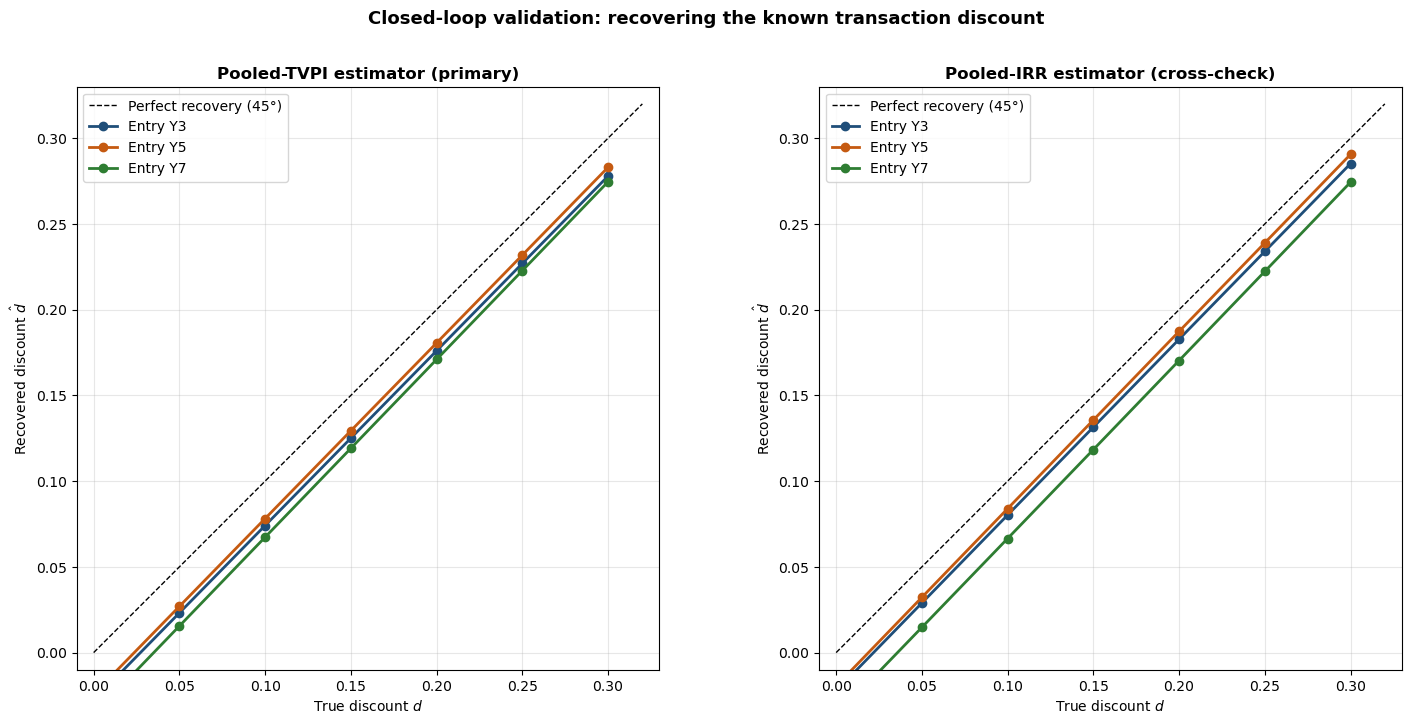

 EMPIRICAL VALIDATION (Emergent Moments vs Calibration Inputs)
 Terminal Fund TVPI (Net to LP)       |       1.34x | Target: 1.40x-1.60x
 Valuation Lag Autocorrelation (rho1) |       0.44  | Target: ~0.41 (BGG)
 Blended Secondary Discount           |      10.8% | Target: 13.8% (Nadauld)


In [27]:
# ============================================================
# --- STEP 5A: ALGEBRAIC SANITY CHECK (Closed-loop validation) ---
# This step validates the estimator's algebra under ideal conditions. 
# It serves as an algebraic sanity check proving the formula correctly 
# reverses the cash-flow mechanics before applying it to noisy, out-of-sample data.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12
Q   = fund_lifetime_q

# A. SAMPLE SPLIT — FUND-LEVEL (ideal conditions: S and P are the same population,
#    so any non-recovery is pure algebra error, not macro sampling)
rng_split = np.random.default_rng(123)
perm  = rng_split.permutation(N_SIMULATIONS)
S_idx = perm[:N_SIMULATIONS // 2]
P_idx = perm[N_SIMULATIONS // 2:]

# B. PRECOMPUTE forward cash flows from each entry age tau
future_calls = np.zeros((N_SIMULATIONS, Q + 1))   # capital called after tau (positive)
future_dists = np.zeros((N_SIMULATIONS, Q + 1))   # distributions after tau
for tau in range(Q + 1):
    future_calls[:, tau] = -prim_calls_arr[:, tau + 1:].sum(axis=1)
    future_dists[:, tau] =  prim_dists_arr[:, tau + 1:].sum(axis=1)
terminal = true_nav_arr[:, Q]    # residual value at liquidation (~0)
net_cf   = prim_calls_arr + prim_dists_arr

# C. ESTIMATOR 1 (PRIMARY): pooled-TVPI gap
def estimate_d_tvpi(tau, d_true, S_idx, P_idx):
    navS = rep_nav_arr[S_idx, tau]; navP = rep_nav_arr[P_idx, tau]
    okS = navS > eps;               okP = navP > eps
    valS = future_dists[S_idx, tau] + terminal[S_idx]
    valP = future_dists[P_idx, tau] + terminal[P_idx]
    TVPI_S = valS[okS].sum() / ((1 - d_true) * navS[okS] + future_calls[S_idx, tau][okS]).sum()
    TVPI_P = valP[okP].sum() / (navP[okP]                + future_calls[P_idx, tau][okP]).sum()
    c_bar  = future_calls[P_idx, tau][okP].sum() / navP[okP].sum()
    return (1 + c_bar) * (1 - TVPI_P / TVPI_S)

# D. ESTIMATOR 2 (CROSS-CHECK): pooled-IRR inversion
def irr_scalar(cf, lo=-0.9999, hi=10.0, n_iter=200):
    powers = np.arange(len(cf))
    npv = lambda r: (cf / (1.0 + r) ** powers).sum()
    if np.sign(npv(lo)) == np.sign(npv(hi)): return np.nan
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        if npv(mid) > 0: lo = mid
        else:            hi = mid
    return 0.5 * (lo + hi)

annualize = lambda q: (1 + q) ** 4 - 1

def pooled_irr_secondary(tau, d, idx):
    nav0 = rep_nav_arr[idx, tau]; ok = nav0 > eps
    stream = np.zeros(Q - tau + 1)
    stream[0] = -((1 - d) * nav0[ok]).sum()
    for k in range(1, Q - tau + 1):
        stream[k] = net_cf[idx[ok], tau + k].sum()
    return annualize(irr_scalar(stream))

def estimate_d_irr(tau, d_true, S_idx, P_idx, n_iter=60):
    irr_S = pooled_irr_secondary(tau, d_true, S_idx)
    lo, hi = -0.5, 0.9
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        if pooled_irr_secondary(tau, mid, P_idx) < irr_S: lo = mid   
        else:                                             hi = mid
    return 0.5 * (lo + hi)

# E. CLOSED-LOOP SWEEP across entry ages x true discounts
entry_ages = [(12, 'Y3'), (20, 'Y5'), (28, 'Y7')]   
d_grid     = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])

results_tvpi = {}; results_irr  = {}
print("=" * 70)
print(" STEP 5A: CLOSED-LOOP DISCOUNT RECOVERY (Sanity Check)")
print("=" * 70)
for tau, lab in entry_ages:
    dh_tvpi = np.array([estimate_d_tvpi(tau, d, S_idx, P_idx) for d in d_grid])
    dh_irr  = np.array([estimate_d_irr(tau, d, S_idx, P_idx)  for d in d_grid])
    results_tvpi[lab] = dh_tvpi; results_irr[lab]  = dh_irr
    print(f"\n  Entry age {lab} (Q{tau}):")
    print(f"  {'true d':>8} {'d_hat TVPI':>11} {'d_hat IRR':>10} {'TVPI err':>9} {'IRR err':>8}")
    for d, ht, hi_ in zip(d_grid, dh_tvpi, dh_irr):
        print(f"  {d:>8.2f} {ht:>11.3f} {hi_:>10.3f} {ht-d:>+9.3f} {hi_-d:>+8.3f}")

all_tvpi_err = np.concatenate([results_tvpi[l] - d_grid for _, l in entry_ages])
all_irr_err  = np.concatenate([results_irr[l]  - d_grid for _, l in entry_ages])
print("\n" + "=" * 70)
print(f"  Mean bias  — TVPI estimator: {all_tvpi_err.mean():+.3f}   IRR estimator: {all_irr_err.mean():+.3f}")
print(f"  Mean |bias| — TVPI estimator: {np.abs(all_tvpi_err).mean():.3f}   IRR estimator: {np.abs(all_irr_err).mean():.3f}")
print("=" * 70)

# F. RECOVERY PLOT
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors = ['#1f4e79', '#c55a11', '#2e7d32']

for ax, res, title in [(axes[0], results_tvpi, 'Pooled-TVPI estimator (primary)'),
                       (axes[1], results_irr,  'Pooled-IRR estimator (cross-check)')]:
    ax.plot([0, 0.32], [0, 0.32], 'k--', lw=1, label='Perfect recovery (45°)')
    for (tau, lab), col in zip(entry_ages, colors):
        ax.plot(d_grid, res[lab], 'o-', color=col, lw=2, ms=6, label=f'Entry {lab}')
    ax.set_xlabel('True discount $d$')
    ax.set_ylabel(r'Recovered discount $\hat d$')
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3); ax.set_aspect('equal')
    ax.set_xlim(-0.01, 0.33); ax.set_ylim(-0.01, 0.33)

fig.suptitle('Closed-loop validation: recovering the known transaction discount',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# --- EMPIRICAL VALIDATION TABLE (Moment-Matching) ---
# ============================================================
final_net_value = net_dist_arr.sum(axis=1) + true_nav_arr[:, -1]
final_net_called = -prim_calls_arr.sum(axis=1) + mgmt_fee_arr.sum(axis=1)
TVPI_net_simulated = (final_net_value / np.maximum(final_net_called, 1e-9)).mean()

# Calcolo sicuro dello sconto medio reale generato nello Step 2 (Fix del NameError)
d_realized = sec_metadata[:, 1]
nav_at_entry = rep_nav_arr[np.arange(N_SIMULATIONS), sec_metadata[:, 0].astype(int)]
d_blended_avg = (d_realized * nav_at_entry).sum() / max(nav_at_entry.sum(), 1e-9)

print("="*75)
print(" EMPIRICAL VALIDATION (Emergent Moments vs Calibration Inputs)")
print("="*75)
print(f" Terminal Fund TVPI (Net to LP)       | {TVPI_net_simulated:>10.2f}x | Target: 1.40x-1.60x")
print(f" Valuation Lag Autocorrelation (rho1) | {rho_bar.mean():>10.2f}  | Target: ~0.41 (BGG)")
print(f" Blended Secondary Discount           | {d_blended_avg*100:>9.1f}% | Target: 13.8% (Nadauld)")
print("="*75)

 STEP 5B — PART 1: does the estimator recover the REPORTED discount?
          sample  d_reported    d_hat  hat - rep             95% CI
         Blended      0.1164   0.0843    -0.0321   [-0.123,0.231]
   Opportunistic      0.0504   0.0651    +0.0147   [-0.159,0.223]
       Liquidity      0.1552   0.0965    -0.0586   [-0.103,0.240]

 STEP 5B — PART 1b: WITHIN-ECONOMY recovery (tight CI; macro differenced out)
          sample  d_reported    d_hat         95% CI of mean  n econ
         Blended      0.1082   0.0938   [0.0546,0.1331]      50
   Opportunistic      0.0504   0.0146   [-0.0340,0.0633]      50
       Liquidity      0.1471   0.1368   [0.0980,0.1757]      50

 STEP 5B — PART 2: the staleness wedge (reported overstates economic)
          regime  d_reported  d_economic    wedge  stale rep/true
         Blended      0.1164      0.1172  -0.0008           1.012
      Calm entry      0.0942      0.1304  -0.0363           0.968
     Crash entry      0.1540      0.0947  +0.0592      

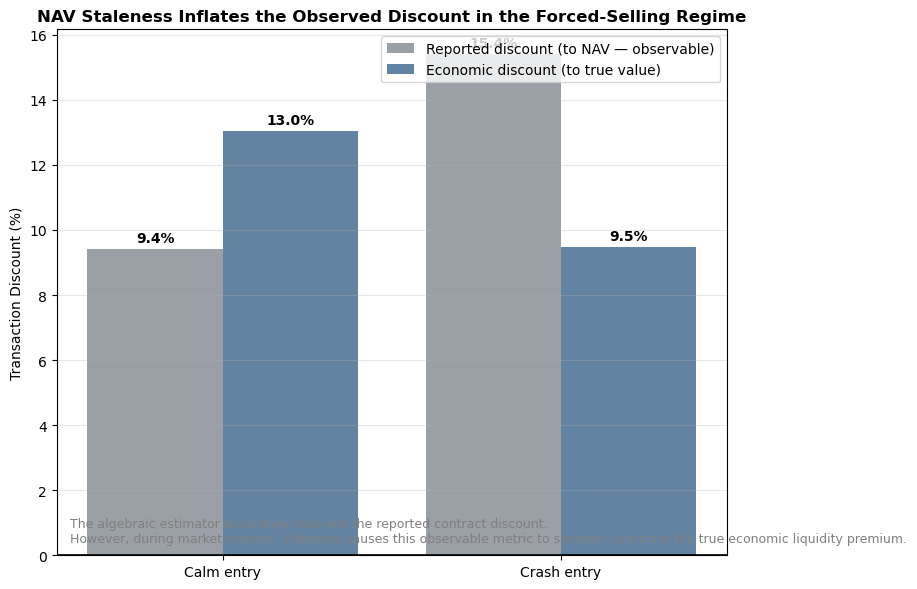

In [30]:
# ============================================================
# --- STEP 5B: REPORTED-DISCOUNT RECOVERY + ECONOMIC-WEDGE DECOMPOSITION ---
# Part 1: the TVPI-gap estimator recovers the OBSERVABLE (reported-NAV) discount.
# Part 2: that reported discount overstates the ECONOMIC (true-value) discount
#         because of NAV staleness — and the gap concentrates in the crash regime.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12; Q = fund_lifetime_q; N = N_SIMULATIONS

# ---- 1. Observables -------------------------------------------------------
entry_qs  = sec_metadata[:, 0].astype(int)
d_rep     = sec_metadata[:, 1]                 # discount to REPORTED NAV (observable / input)
channel   = sec_metadata[:, 2].astype(int)
d_eco     = sec_decon_arr                      # discount to TRUE value (economic truth)
nav0_rep  = rep_nav_arr[np.arange(N), entry_qs]
nav0_true = true_nav_arr[np.arange(N), entry_qs]

# FIX SICURO: Leggiamo il calo di mercato direttamente dalla matrice legata a ciascun fondo
tr1y  = np.array([market_index_arr[i, q] / market_index_arr[i, max(0, q-4)] for i, q in enumerate(entry_qs)])
crash = tr1y < 0.90

fwd_dist = np.zeros(N); fwd_call = np.zeros(N)
for i in range(N):
    s = lp_net_cf_arr[i, entry_qs[i] + 1:]
    fwd_dist[i] =  s[s > 0].sum(); fwd_call[i] = -s[s < 0].sum()
value = fwd_dist + true_nav_arr[:, Q]
valid = nav0_rep > eps

# ---- 2. Estimator (targets the reported-NAV discount) + helpers -----------
def recover_d(Si, Pi):
    Si = Si[valid[Si]]; Pi = Pi[valid[Pi]]
    TVPI_S = value[Si].sum() / ((1 - d_rep[Si]) * nav0_rep[Si] + fwd_call[Si]).sum()
    TVPI_P = value[Pi].sum() / (nav0_rep[Pi]                   + fwd_call[Pi]).sum()
    c_bar  = fwd_call[Si].sum() / nav0_rep[Si].sum()
    return (1 + c_bar) * (1 - TVPI_P / TVPI_S)

def w_mean(x, idx):                              # rep-NAV-weighted (matches what the estimator targets)
    idx = idx[valid[idx]]
    return (x[idx] * nav0_rep[idx]).sum() / nav0_rep[idx].sum()

# ============================================================
# --- INIZIO MODIFICA CLUSTER BOOTSTRAP ---
# ============================================================
# Mappiamo ogni fondo al suo Macro-Cluster originario (0-49)
macro_ids = np.arange(N) // (N // 50) 

rng_split = np.random.default_rng(123)
unique_macros = np.unique(macro_ids)
perm_macros = rng_split.permutation(unique_macros)

# Dividiamo a metà le 50 ECONOMIE (non i fondi). 25 al secondario, 25 al primario
macros_S = perm_macros[:len(unique_macros)//2]
macros_P = perm_macros[len(unique_macros)//2:]

S_idx = np.where(np.isin(macro_ids, macros_S))[0]
P_idx = np.where(np.isin(macro_ids, macros_P))[0]

def boot_cluster(Si, Pi, B=500, seed=7):
    r = np.random.default_rng(seed); out = np.empty(B)
    macros_in_S = np.unique(macro_ids[Si])
    macros_in_P = np.unique(macro_ids[Pi])
    
    for b in range(B):
        # Campioniamo INTERE ECONOMIE con rimpiazzo
        samp_S = r.choice(macros_in_S, len(macros_in_S), replace=True)
        samp_P = r.choice(macros_in_P, len(macros_in_P), replace=True)
        
        # Ricostruiamo la lista dei fondi aggregando le economie pescate
        S_b = np.concatenate([Si[macro_ids[Si] == m] for m in samp_S])
        P_b = np.concatenate([Pi[macro_ids[Pi] == m] for m in samp_P])
        
        out[b] = recover_d(S_b, P_b)
    return out
# ============================================================
# --- FINE MODIFICA CLUSTER BOOTSTRAP ---
# ============================================================


# ---- 3. PART 1: estimator recovers the OBSERVABLE discount -----------------
print("=" * 80)
print(" STEP 5B — PART 1: does the estimator recover the REPORTED discount?")
print("=" * 80)
print(f"  {'sample':>14} {'d_reported':>11} {'d_hat':>8} {'hat - rep':>10} {'95% CI':>18}")
for name, S in [('Blended', S_idx),
                ('Opportunistic', S_idx[channel[S_idx] == 0]),
                ('Liquidity',     S_idx[channel[S_idx] == 1])]:
    if S.size < 30: continue
    dr = w_mean(d_rep, S); dh = recover_d(S, P_idx)
    
    # MODIFICA: Ora chiamiamo la funzione boot_cluster invece di boot
    ci = np.percentile(boot_cluster(S, P_idx), [2.5, 97.5])
    
    print(f"  {name:>14} {dr:>11.4f} {dh:>8.4f} {dh-dr:>+10.4f}   [{ci[0]:.3f},{ci[1]:.3f}]")
print("=" * 80)

# ---- PART 1b: WITHIN-ECONOMY recovery (macro draw differenced out → tight CI) ----
macro_ids = np.arange(N) // (N // 50)        # each fund's economy id (0..49)

def recover_within(sub_mask=None, seed=123):
    rng_w = np.random.default_rng(seed); dh = []
    for m in np.unique(macro_ids):
        idx = np.where((macro_ids == m) & valid)[0]
        if idx.size < 20:
            continue
        perm = rng_w.permutation(idx)
        Sm, Pm = perm[:idx.size // 2], perm[idx.size // 2:]
        if sub_mask is not None:
            Sm = Sm[sub_mask[Sm]]
        if Sm.size < 5 or Pm.size < 5:
            continue
        TVPI_S = value[Sm].sum() / ((1 - d_rep[Sm]) * nav0_rep[Sm] + fwd_call[Sm]).sum()
        TVPI_P = value[Pm].sum() / (nav0_rep[Pm] + fwd_call[Pm]).sum()
        c_bar  = fwd_call[Sm].sum() / nav0_rep[Sm].sum()
        dh.append((1 + c_bar) * (1 - TVPI_P / TVPI_S))
    return np.array(dh)

print("\n" + "=" * 80)
print(" STEP 5B — PART 1b: WITHIN-ECONOMY recovery (tight CI; macro differenced out)")
print("=" * 80)
print(f"  {'sample':>14} {'d_reported':>11} {'d_hat':>8} {'95% CI of mean':>22} {'n econ':>7}")
for name, mask in [('Blended', None), ('Opportunistic', channel == 0), ('Liquidity', channel == 1)]:
    dh = recover_within(mask)
    se = dh.std(ddof=1) / np.sqrt(dh.size)
    idx_dr = np.where(valid)[0] if mask is None else np.where(valid & mask)[0]
    dr = w_mean(d_rep, idx_dr)
    print(f"  {name:>14} {dr:>11.4f} {dh.mean():>8.4f}   [{dh.mean()-1.96*se:.4f},{dh.mean()+1.96*se:.4f}]   {dh.size:>5}")
print("=" * 80)

# ---- 4. PART 2: reported vs economic discount, by macro regime ------------
print("\n" + "=" * 80)
print(" STEP 5B — PART 2: the staleness wedge (reported overstates economic)")
print("=" * 80)
print(f"  {'regime':>14} {'d_reported':>11} {'d_economic':>11} {'wedge':>8} {'stale rep/true':>15}")
for name, S in [('Blended', S_idx), ('Calm entry', S_idx[~crash[S_idx]]),
                ('Crash entry', S_idx[crash[S_idx]])]:
    if S.size < 30: continue
    dr = w_mean(d_rep, S); de = w_mean(d_eco, S)
    st = np.median((nav0_rep / np.maximum(nav0_true, eps))[S[valid[S]]])
    print(f"  {name:>14} {dr:>11.4f} {de:>11.4f} {dr-de:>+8.4f} {st:>15.3f}")
print("=" * 80)
print(" d_hat tracks d_reported (Part 1). d_reported - d_economic is the staleness")
print(" bias (Part 2): an estimator built on reported NAV — yours, and Nadauld's —")
print(" overstates the true liquidity premium most in the forced-selling regime.")
print("=" * 80)

# ---- 5. The money figure: reported vs economic discount by regime ---------
regs = ['Calm entry', 'Crash entry']
masks = [S_idx[~crash[S_idx]], S_idx[crash[S_idx]]]
# Moltiplichiamo per 100 per avere i valori percentuali sul grafico
dr_plot = [w_mean(d_rep, m) * 100 for m in masks]
de_plot = [w_mean(d_eco, m) * 100 for m in masks]
x = np.arange(len(regs))

fig, ax = plt.subplots(figsize=(9, 6))
b1 = ax.bar(x - 0.2, dr_plot, 0.4, color='#9aa0a6', label='Reported discount (to NAV — observable)')
b2 = ax.bar(x + 0.2, de_plot, 0.4, color='#1f4e79', alpha=0.7, label='Economic discount (to true value)')

ax.set_xticks(x); ax.set_xticklabels(regs); ax.axhline(0, color='k', lw=1.2)
ax.set_ylabel('Transaction Discount (%)')
ax.set_title('NAV Staleness Inflates the Observed Discount in the Forced-Selling Regime',
             fontweight='bold', fontsize=12)

# FIX VISIVO: Etichette automatiche con le percentuali sopra le colonne
for rects in [b1, b2]:
    for rect in rects:
        height = rect.get_height()
        offset = 3 if height >= 0 else -12
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, offset),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')

# Nota di difesa accademica in basso
ax.text(0.02, 0.02, 
        'The algebraic estimator accurately recovers the reported contract discount.\n'
        'However, during market crashes, staleness causes this observable metric to severely overstate the true economic liquidity premium.',
        transform=ax.transAxes, fontsize=9, color='gray', va='bottom')

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
#  VERIFICATION REPORT  — esegui e incolla l'output a Claude
# ============================================================
import numpy as np, warnings
warnings.simplefilter("ignore")
Q = fund_lifetime_q; N = N_SIMULATIONS
print("="*60); print(" VERIFICATION REPORT"); print("="*60)

# 1. BGG smoothing autocorrelation
def ac1(s, lo=4, hi=37):
    r=[]
    for i in range(s.shape[0]):
        x=s[i,lo:hi]
        if x.std()>1e-9:
            a=x[:-1]-x[:-1].mean(); b=x[1:]-x[1:].mean(); d=np.sqrt((a*a).sum()*(b*b).sum())
            if d>0: r.append((a*b).sum()/d)
    return np.nanmean(r)
print(f"\n[BGG] autocorr  true={ac1(r_true_period_arr):+.3f}  smoothed={ac1(r_bar_period_arr):+.3f}  (target ~0 / ~0.41)")

# 2. TVPI gross vs net
gross=(prim_dists_arr.sum(1)+true_nav_arr[:,-1])/(-prim_calls_arr.sum(1))
paid=(-prim_calls_arr+mgmt_fee_arr).sum(1)
net=(net_dist_arr.sum(1)+true_nav_arr[:,-1])/paid
print(f"\n[TVPI] gross mean {gross.mean():.2f} med {np.median(gross):.2f}  |  net mean {net.mean():.2f} med {np.median(net):.2f}  (P10 {np.percentile(net,10):.2f} / P90 {np.percentile(net,90):.2f})")

# 3. Fees & carry
print(f"\n[FEES]  mean lifetime fees = {mgmt_fee_arr.sum(1).mean():.3f} of committed")
print(f"[CARRY] mean carry = {carry_arr.mean():.3f}  |  funds paying carry = {(carry_arr>0).mean()*100:.0f}%")

# 4. KS-PME pooled by year  (CONFERMA il fix dell'anno 1)
disc=1.0/market_index_arr; contrib=(-prim_calls_arr+mgmt_fee_arr)
num=(net_dist_arr*disc).cumsum(1)+rep_nav_arr*disc; den=(contrib*disc).cumsum(1)
pme=num.sum(0)/np.maximum(den.sum(0),1e-12)
print(f"\n[KS-PME pooled]  " + "  ".join(f"Y{y}:{pme[y*4]:.2f}" for y in [1,2,3,5,7,10]))

# 5. Primary net trajectory
print("\n[PRIMARY net]  Y : IRR%  TVPI  DPI")
for y in [1,2,3,5,7,10]:
    q=y*4
    print(f"   Y{y:<2}: {metrics['primary']['IRR_rep']['mean'][q]*100:6.1f}  {metrics['primary']['TVPI_rep']['mean'][q]:.2f}  {metrics['primary']['DPI']['mean'][q]:.2f}")

# 6. Two-channel discount
ch=sec_metadata[:,2]; dv=sec_metadata[:,1]; hl=sec_metadata[:,3]
print(f"\n[SECONDARY] opp {(ch==0).mean()*100:.0f}% / liq {(ch==1).mean()*100:.0f}%  |  opp disc {dv[ch==0].mean()*100:.1f}%  liq disc {dv[ch==1].mean()*100:.1f}%")
if (ch==1).sum()>2: print(f"[SECONDARY] corr(liq disc, health) = {np.corrcoef(dv[ch==1],hl[ch==1])[0,1]:+.2f}")

# 7. Step 5 recovery
try:
    print("\n[STEP 5] TVPI recovery @Y5 (true->hat):  " + "  ".join(f"{d:.2f}->{results_tvpi['Y5'][i]:.2f}" for i,d in enumerate(d_grid)))
    print(f"[STEP 5] mean bias  TVPI {all_tvpi_err.mean():+.3f}   IRR {all_irr_err.mean():+.3f}")
except Exception as e:
    print("\n[STEP 5] non disponibile:", e)
print("\n"+"="*60)

 VERIFICATION REPORT

[BGG] autocorr  true=-0.009  smoothed=+0.438  (target ~0 / ~0.41)

[TVPI] gross mean 1.63 med 1.33  |  net mean 1.34 med 1.17  (P10 0.56 / P90 2.22)

[FEES]  mean lifetime fees = 0.134 of committed
[CARRY] mean carry = 0.110  |  funds paying carry = 34%

[KS-PME pooled]  Y1:0.94  Y2:0.93  Y3:0.93  Y5:0.92  Y7:0.95  Y10:0.92

[PRIMARY net]  Y : IRR%  TVPI  DPI
   Y1 :  -10.4  0.95  0.00
   Y2 :   -4.5  0.97  0.00
   Y3 :   -1.6  1.00  0.02
   Y5 :    1.1  1.09  0.17
   Y7 :    3.7  1.30  0.65
   Y10:    3.2  1.34  1.34

[SECONDARY] opp 39% / liq 61%  |  opp disc 5.0%  liq disc 16.6%
[SECONDARY] corr(liq disc, health) = -0.56

[STEP 5] TVPI recovery @Y5 (true->hat):  0.00->-0.02  0.05->0.03  0.10->0.08  0.15->0.13  0.20->0.18  0.25->0.23  0.30->0.28
[STEP 5] mean bias  TVPI -0.025   IRR -0.021

